# Риск хотя бы одного отказа среди N серверов

## Цель

Воспроизвести прикладной кейс семинара S03: при вероятности отказа одного сервера $p=0.001$ показать, как с ростом числа независимых серверов растёт вероятность хотя бы одного отказа:

$$P_N=1-(1-p)^N.$$

Это учебная модель. Независимость может нарушаться из-за общей электросети, зоны доступности, сети или общего дефекта ПО.

## Параметры и вычисление

In [1]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

p = 0.001
control_n = np.array([1, 10, 100, 500, 1000, 5000])

def at_least_one_failure(n, p=p):
    return 1 - (1 - p) ** n

control_probability = np.array([at_least_one_failure(int(n)) for n in control_n])
table = pd.DataFrame({
    "Число серверов N": control_n,
    "Вероятность хотя бы одного отказа": control_probability,
    "Вероятность, %": 100 * control_probability,
})
table.round({"Вероятность хотя бы одного отказа": 6, "Вероятность, %": 3})

,Число серверов N,Вероятность хотя бы одного отказа,"Вероятность, %"
0,1,0.001000,0.100
1,10,0.009955,0.996
2,100,0.095208,9.521
3,500,0.393621,39.362
4,1000,0.632305,63.230
5,5000,0.993279,99.328


## График

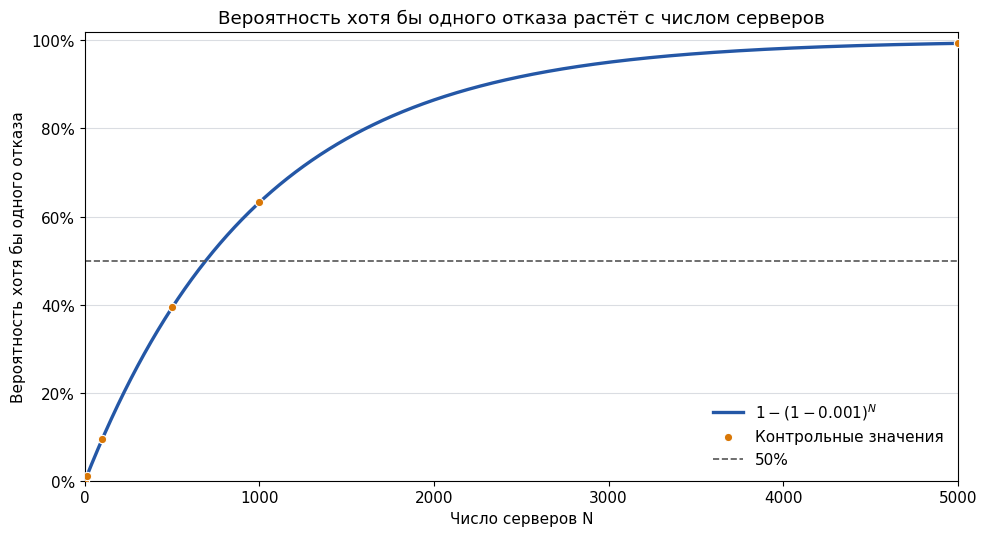

In [2]:
n = np.arange(1, 5001)
probability = at_least_one_failure(n)

plt.rcParams.update({"font.size": 11})
fig, ax = plt.subplots(figsize=(10, 5.5))
ax.plot(n, probability, color="#2457A6", linewidth=2.4, label=r"$1-(1-0.001)^N$")
ax.scatter(control_n, control_probability, color="#D97706", edgecolor="white", linewidth=0.8, zorder=3, label="Контрольные значения")
ax.axhline(0.5, color="#555555", linestyle="--", linewidth=1.2, label="50%")
ax.set_title("Вероятность хотя бы одного отказа растёт с числом серверов")
ax.set_xlabel("Число серверов N")
ax.set_ylabel("Вероятность хотя бы одного отказа")
ax.yaxis.set_major_formatter(PercentFormatter(1.0))
ax.set_xlim(0, 5000)
ax.set_ylim(0, 1.02)
ax.grid(axis="y", color="#D1D5DB", linewidth=0.8, alpha=0.8)
ax.legend(frameon=False, loc="lower right")
fig.tight_layout()
plt.show()

## Проверки

In [3]:
expected = np.array([
    0.001,
    1 - 0.999**10,
    1 - 0.999**100,
    1 - 0.999**500,
    1 - 0.999**1000,
    1 - 0.999**5000,
])
assert np.allclose(control_probability, expected, rtol=0, atol=1e-12)
assert np.all(np.diff(probability) > 0)
threshold_n = math.ceil(math.log(0.5) / math.log(0.999))
assert threshold_n == 693
print("Проверки пройдены. Минимальное N для риска не ниже 50%:", threshold_n)

Проверки пройдены. Минимальное N для риска не ниже 50%: 693


## Вывод

При независимых отказах индивидуальный риск $0.1\%$ не остаётся «маленьким» на уровне всей инфраструктуры: около $N=693$ совокупный риск пересекает $50\%$, а при $N=1000$ достигает примерно $63.2\%$. Это не прогноз для конкретной системы, а демонстрация эффекта масштаба при заданных предпосылках.